# Genetic ties and EpiLink compatibility

**A reproducible examination of the current percentile convention and a midpoint alternative.**

EpiLink compares an observed genetic distance with simulated distances. Its current empirical cumulative distribution counts **all simulated values at or below the observation**. That is a valid CDF. Applying the compatibility transformation to that CDF can, however, give a low score to a very common discrete outcome.

This notebook:

1. Reproduces the 90%-zero, all-zero, and 30–40–30 examples exactly.
2. Compares the current convention with a midpoint treatment of ties.
3. Retrieves the actual genetic draws from EpiLink for direct transmission and a shared source.
4. Examines genetic scores and illustrative combined genetic–temporal scores using **the same draws** under both conventions.
5. Checks edge cases and separates the demonstrated mathematical effect from questions requiring a full benchmark.

The midpoint scorer exists only in this notebook. Running the notebook does not modify EpiLink or rerun the thesis evaluation pipeline. All examples use synthetic data; no patient records are required.

**Run:** use a Python 3.10+ Jupyter kernel with `epilink==0.1.5`, NumPy, SciPy, pandas, Matplotlib, and IPython installed, then run all cells in order. If the EpiLink source checkout is next to this evaluation repository, the notebook prefers that checkout and reports its path and revision. Otherwise it uses the installed package. Executed tables and plots are embedded below.


In [ ]:
from pathlib import Path
import inspect
import platform
import subprocess
import sys

# Prefer the adjacent source checkout when running from epilink-evaluation.
source_candidates = [
    Path.cwd().parent / "epilink" / "src",
    Path.cwd() / "src",
    Path.cwd() / "epilink" / "src",
]
for candidate in source_candidates:
    if (candidate / "epilink" / "__init__.py").is_file():
        sys.path.insert(0, str(candidate.resolve()))
        break

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy.stats import percentileofscore
from IPython.display import display, Markdown
import epilink
from epilink import EpiLink, InfectiousnessToTransmission, NaturalHistoryParameters

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.18,
    }
)
CURRENT = "#C05A32"
MIDPOINT = "#176B87"
MASS = "#748699"
SEED = 12345
MC_SAMPLES = 10_000

model_source = Path(inspect.getfile(EpiLink)).resolve()
try:
    source_revision = subprocess.run(
        ["git", "-C", str(model_source.parent), "rev-parse", "HEAD"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    source_revision = "Not available (for example, an installed distribution)."

display(
    pd.Series(
        {
            "Python": platform.python_version(),
            "EpiLink": epilink.__version__,
            "NumPy": np.__version__,
            "SciPy": scipy.__version__,
            "pandas": pd.__version__,
            "Matplotlib": matplotlib.__version__,
            "EpiLink source": str(model_source),
            "Source revision": source_revision,
            "Random seed": SEED,
            "Draws per scenario": MC_SAMPLES,
        },
        name="Execution provenance",
    ).to_frame()
)

,Execution provenance
Python,3.11.6
EpiLink,0.1.5
NumPy,2.4.3
SciPy,1.17.1
pandas,3.0.1
Matplotlib,3.10.8
EpiLink source,/Users/ydnkka/Desktop/PhD Project/Projects/epi...
Source revision,0871f1182345d1763b7e70b986f7967f8908ddb9
Random seed,12345
Draws per scenario,10000


## 1. What the two conventions calculate

For genetic draws $G_1,\ldots,G_N$ and an observed distance $g$, the current implementation uses

$$
F_{\mathrm{right}}(g)=\frac{\#\{G_r\leq g\}}{N},\qquad
c(F)=1-2|F-0.5|.
$$

It gives compatibility 1 **only if the empirical percentile is exactly 0.5**. Repeated mutation counts create jumps that can skip 0.5. A median observation need not have $F_{\mathrm{right}}=0.5$.

The alternative considered here places the observation halfway through its tied values:

$$F_{\mathrm{mid}}(g)=\frac{\#\{G_r<g\}+\frac12\#\{G_r=g\}}{N}.$$

This is the average of the strict and right-inclusive percentiles, equivalent to SciPy's `percentileofscore(..., kind="mean") / 100`. It is **not** SciPy's slightly different `kind="rank"` convention. $F_{\mathrm{mid}}$ is a midpoint percentile, not the ordinary right-continuous CDF.

Both versions then use the same transformation $c$. They measure percentile centrality, not a probability of transmission or the probability mass of the observed count. A better result in these examples does not by itself establish better epidemiological discrimination.


In [ ]:
def empirical_percentiles(draws, observations, convention="right"):
    """Evaluate right-inclusive or midpoint percentiles without changing the draws."""
    draws = np.asarray(draws, dtype=float)
    observations = np.asarray(observations, dtype=float)
    if draws.ndim != 1 or draws.size == 0 or not np.all(np.isfinite(draws)):
        raise ValueError("draws must be a non-empty, finite one-dimensional array")
    if not np.all(np.isfinite(observations)):
        raise ValueError("observations must be finite")
    ordered = np.sort(draws)
    right = np.searchsorted(ordered, observations, side="right")
    if convention == "right":
        return right / draws.size
    if convention == "midpoint":
        left = np.searchsorted(ordered, observations, side="left")
        return (left + right) / (2 * draws.size)
    raise ValueError("convention must be 'right' or 'midpoint'")


def compatibility(percentiles):
    return 1 - 2 * np.abs(np.asarray(percentiles, dtype=float) - 0.5)


def score_table(draws, observations=None):
    draws = np.asarray(draws)
    if observations is None:
        observations = np.unique(draws)
    observations = np.atleast_1d(np.asarray(observations, dtype=float))
    right = empirical_percentiles(draws, observations, "right")
    midpoint = empirical_percentiles(draws, observations, "midpoint")
    return pd.DataFrame(
        {
            "Observed distance": observations,
            "Count equal": [(draws == g).sum() for g in observations],
            "Mass at observation": [(draws == g).mean() for g in observations],
            "F right": right,
            "F midpoint": midpoint,
            "Current score": compatibility(right),
            "Midpoint score": compatibility(midpoint),
        }
    )

## 2. Exact examples: a common outcome can receive a low score

These are deliberately constructed arrays, so Monte Carlo noise cannot explain the differences.

- **90% zero:** the current percentile at zero is 0.9 and compatibility is 0.2. The midpoint percentile is 0.45 and compatibility is 0.9.
- **All zero:** the current percentile at zero is 1 and compatibility is 0. The midpoint percentile is 0.5 and compatibility is 1.
- **30–40–30:** 30 draws are zero, 40 are one, and 30 are two. The current CDF jumps from 0.3 to 0.7 at one. The median and modal value therefore receives 0.6; the midpoint convention gives it 1.

These are genetic **component** scores. EpiLink subsequently multiplies genetic and temporal components within a scenario, then sums across the selected scenarios.


In [ ]:
toy_draws = {
    "90% zero": np.repeat([0, 1], [90, 10]),
    "All zero": np.zeros(100, dtype=int),
    "30–40–30": np.repeat([0, 1, 2], [30, 40, 30]),
}
toy_tables = pd.concat(
    [score_table(draws).assign(Example=name) for name, draws in toy_draws.items()],
    ignore_index=True,
)
display(toy_tables.set_index(["Example", "Observed distance"]).round(4))

for name, observed, expected_current, expected_midpoint in [
    ("90% zero", 0, 0.2, 0.9),
    ("All zero", 0, 0.0, 1.0),
    ("30–40–30", 1, 0.6, 1.0),
]:
    row = score_table(toy_draws[name], [observed]).iloc[0]
    np.testing.assert_allclose(row["Current score"], expected_current)
    np.testing.assert_allclose(row["Midpoint score"], expected_midpoint)
    np.testing.assert_allclose(
        row["Current score"], EpiLink.compatibility_score(observed, toy_draws[name])[1]
    )
print("All three worked examples agree with the stated calculations and EpiLink.")

Count equal  Mass at observation  F right  \
Example  Observed distance                                              
90% zero 0.0                         90                  0.9      0.9   
         1.0                         10                  0.1      1.0   
All zero 0.0                        100                  1.0      1.0   
30–40–30 0.0                         30                  0.3      0.3   
         1.0                         40                  0.4      0.7   
         2.0                         30                  0.3      1.0   

                            F midpoint  Current score  Midpoint score  
Example  Observed distance                                             
90% zero 0.0                      0.45            0.2             0.9  
         1.0                      0.95            0.0             0.1  
All zero 0.0                      0.50            0.0             1.0  
30–40–30 0.0                      0.15            0.6             0.3  
         1.0                      0.50            0.6             1.0  
         2.0                      0.85            0.0             0.3

All three worked examples agree with the stated calculations and EpiLink.


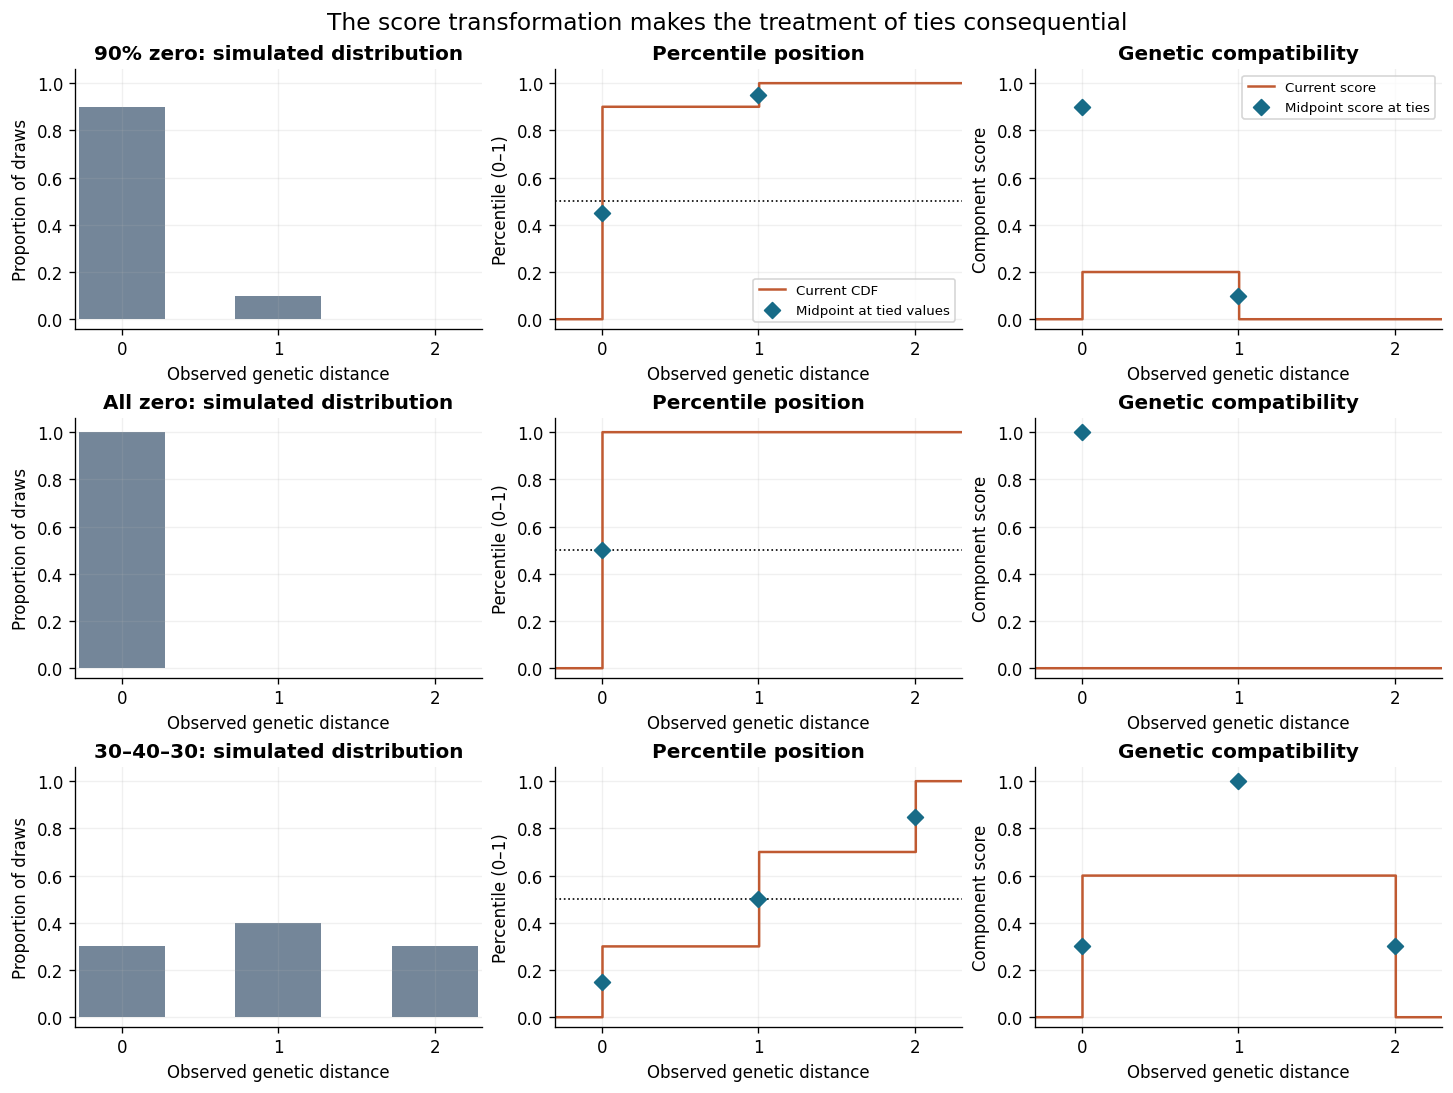

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9), layout="constrained")
for row, (name, draws) in enumerate(toy_draws.items()):
    support, counts = np.unique(draws, return_counts=True)
    x = np.linspace(-0.3, 2.3, 521)
    # Integer support points are included exactly for midpoint markers.
    current = empirical_percentiles(draws, x, "right")
    table = score_table(draws, support)

    axes[row, 0].bar(support, counts / draws.size, width=0.55, color=MASS)
    axes[row, 0].set_title(f"{name}: simulated distribution")
    axes[row, 0].set_ylabel("Proportion of draws")

    axes[row, 1].step(x, current, where="post", color=CURRENT, label="Current CDF")
    axes[row, 1].scatter(
        support,
        table["F midpoint"],
        color=MIDPOINT,
        marker="D",
        s=45,
        zorder=4,
        label="Midpoint at tied values",
    )
    axes[row, 1].axhline(0.5, color="black", linestyle=":", linewidth=1)
    axes[row, 1].set_title("Percentile position")
    axes[row, 1].set_ylabel("Percentile (0–1)")

    axes[row, 2].step(
        x, compatibility(current), where="post", color=CURRENT, label="Current score"
    )
    axes[row, 2].scatter(
        support,
        table["Midpoint score"],
        color=MIDPOINT,
        marker="D",
        s=45,
        zorder=4,
        label="Midpoint score at ties",
    )
    axes[row, 2].set_title("Genetic compatibility")
    axes[row, 2].set_ylabel("Component score")
    for ax in axes[row]:
        ax.set(
            xlim=(-0.3, 2.3),
            ylim=(-0.04, 1.06),
            xticks=[0, 1, 2],
            xlabel="Observed genetic distance",
        )
axes[0, 1].legend(fontsize=8, loc="lower right")
axes[0, 2].legend(fontsize=8, loc="upper right")
fig.suptitle(
    "The score transformation makes the treatment of ties consequential", fontsize=14
)
plt.show()

**Reading the plots:** the orange steps use the current CDF convention. Blue diamonds replace the value only at an observation that equals one or more draws. Between tied values, the two percentile conventions agree. The diamonds are not an interpolated or smoothed CDF.

### How the zero mass controls the score at zero

For a non-negative distribution, let $p_0$ be the fraction of draws equal to zero. Then

$$c_{\mathrm{right}}(0)=1-2|p_0-0.5|,\qquad c_{\mathrm{mid}}(0)=p_0.$$

Once more than half the draws are zero, the current score at zero **decreases as zero becomes more common**. Increasing the number of simulations does not remove a genuine point mass; it only estimates that mass more precisely.

The midpoint rule does **not** uniformly raise scores. At zero, its score exceeds the current score only when more than two thirds of the draws are zero. Below that threshold (apart from zero mass), the midpoint score is lower. The actual EpiLink examples below should therefore be read as a comparison, not as a demonstration that midpoint scores are always larger.


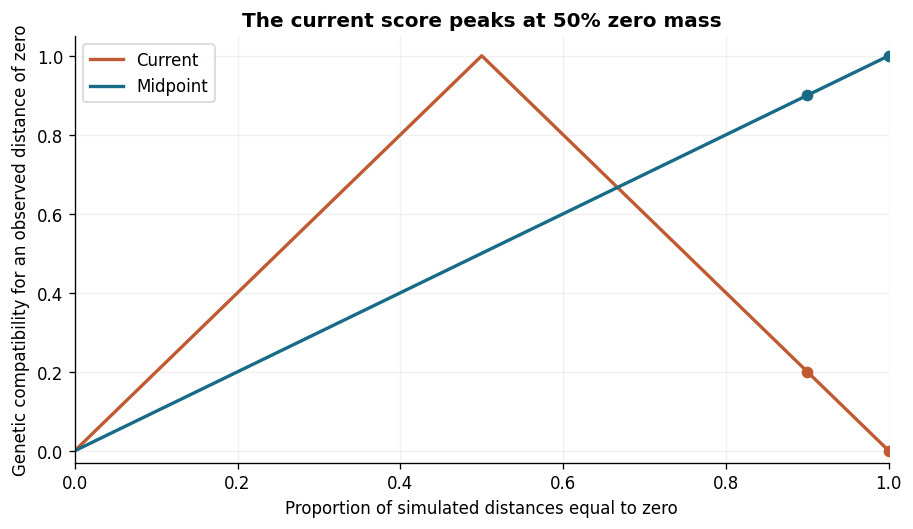

In [ ]:
p_zero = np.linspace(0, 1, 201)
fig, ax = plt.subplots(figsize=(7.5, 4.3), layout="constrained")
ax.plot(p_zero, compatibility(p_zero), color=CURRENT, linewidth=2, label="Current")
ax.plot(
    p_zero, compatibility(p_zero / 2), color=MIDPOINT, linewidth=2, label="Midpoint"
)
ax.scatter([0.9, 1], [0.2, 0], color=CURRENT, zorder=3)
ax.scatter([0.9, 1], [0.9, 1], color=MIDPOINT, zorder=3)
ax.set(
    xlabel="Proportion of simulated distances equal to zero",
    ylabel="Genetic compatibility for an observed distance of zero",
    title="The current score peaks at 50% zero mass",
    xlim=(0, 1),
    ylim=(-0.03, 1.05),
)
ax.legend()
plt.show()

## 3. Verify the conventions and their limits

The following checks compare the notebook with EpiLink's scalar API, its vectorised scoring behaviour later in the notebook, and SciPy's independent percentile implementation.

Three qualifications matter:

- Ties **can**, but need not, prevent the current score reaching 1. A 50–50 distribution gives the lower value a current score of 1.
- The midpoint convention also need not reach 1. With masses 10%, 30%, and 60%, none of the midpoint percentiles is exactly 0.5.
- Neither score is a probability mass or likelihood. With half the draws at zero and half at two, an unobserved value of one has percentile 0.5 and scores 1 under both rules. Centrality can therefore be high in a gap in the simulated distribution.

For observations unequal to every draw, the two conventions are identical. This matters for **non-integer scaled TN93 distances** in the Boston application: the midpoint change acts at exact matches, such as zero or an exactly integer count. This notebook does not round distances or introduce an equality tolerance.


In [ ]:
test_cases = {
    **toy_draws,
    "50–50": np.repeat([0, 1], [50, 50]),
    "10–30–60": np.repeat([0, 1, 2], [10, 30, 60]),
    "Gap in support": np.repeat([0, 2], [50, 50]),
}
observations = np.array([-1, 0, 0.25, 0.5, 1, 1.5, 2, 3])
for name, draws in test_cases.items():
    right = empirical_percentiles(draws, observations, "right")
    midpoint = empirical_percentiles(draws, observations, "midpoint")
    np.testing.assert_allclose(
        right, percentileofscore(draws, observations, kind="weak") / 100
    )
    np.testing.assert_allclose(
        midpoint, percentileofscore(draws, observations, kind="mean") / 100
    )
    np.testing.assert_allclose(
        right, [EpiLink.percentile_score(g, draws) for g in observations]
    )
    np.testing.assert_allclose(
        compatibility(right),
        [EpiLink.compatibility_score(g, draws)[1] for g in observations],
    )
    nonmatches = ~np.isin(observations, draws)
    np.testing.assert_allclose(right[nonmatches], midpoint[nonmatches])
    assert np.all((compatibility(midpoint) >= 0) & (compatibility(midpoint) <= 1))

np.testing.assert_allclose(score_table(test_cases["50–50"], [0])["Current score"], 1)
assert score_table(test_cases["10–30–60"])["Midpoint score"].max() < 1
gap_row = score_table(test_cases["Gap in support"], [1]).iloc[0]
np.testing.assert_allclose(gap_row[["Current score", "Midpoint score"]], 1)
assert gap_row["Mass at observation"] == 0

# At a unique draw, the percentile change is 1/(2N), and the score change is <= 1/N.
unique_draws = np.arange(100, dtype=float) + 0.25
unique_scores = score_table(unique_draws)
assert (
    np.max(np.abs(unique_scores["Current score"] - unique_scores["Midpoint score"]))
    <= 0.01 + 1e-12
)

# Repeating every draw increases N but preserves the probability masses and the scores.
np.testing.assert_allclose(
    score_table(toy_draws["90% zero"])[["Current score", "Midpoint score"]],
    score_table(np.tile(toy_draws["90% zero"], 100))[
        ["Current score", "Midpoint score"]
    ],
)
print(
    "Passed: EpiLink and SciPy agreement, tails, exact ties, nonmatches, gaps, finite-N behaviour, and replicated draws."
)
display(
    pd.concat(
        [
            score_table(test_cases[name]).assign(Example=name)
            for name in ["50–50", "10–30–60"]
        ]
    )
    .set_index(["Example", "Observed distance"])
    .round(4)
)

Passed: EpiLink and SciPy agreement, tails, exact ties, nonmatches, gaps, finite-N behaviour, and replicated draws.


Count equal  Mass at observation  F right  \
Example  Observed distance                                              
50–50    0.0                         50                  0.5      0.5   
         1.0                         50                  0.5      1.0   
10–30–60 0.0                         10                  0.1      0.1   
         1.0                         30                  0.3      0.4   
         2.0                         60                  0.6      1.0   

                            F midpoint  Current score  Midpoint score  
Example  Observed distance                                             
50–50    0.0                      0.25            1.0             0.5  
         1.0                      0.75            0.0             0.5  
10–30–60 0.0                      0.05            0.2             0.1  
         1.0                      0.25            0.8             0.5  
         2.0                      0.70            0.0             0.6

## 4. Retrieve the genetic distributions used by EpiLink

The public property `model.draws_by_scenario[label]["genetic_draws"]` exposes the precomputed Monte Carlo draws. Labels `ad(0)` and `ca(0,0)` identify direct transmission and co-primary infection from the same source, respectively. Each scenario also stores `time_draws` and `branch_draws`.

The constructor generates these arrays once. Internally, `_simulate_genetic_draws` maps branch lengths to expected mutation counts and, for `mutation_process="stochastic"`, draws Poisson counts. `simulate_scenario_draws` alone returns **time and branch-length draws**, not genetic draws. Read the cached public arrays to examine the distributions actually used by an initialised instance.

We use 10,000 draws and the Chapter 3 baseline represented in this repository's `config.yaml`. Parameters are explicit so that a change in package defaults does not silently change this example. In particular, Gamma testing-delay shape 1 and scale 1 give the chapter's mean and CV of 1; the inspected package's default shape is 2. These examples demonstrate the scoring behaviour under the stated parameters, rather than reproducing every result in the thesis.

The genetic arrays are **marginal distributions within a scenario**. They are not conditioned on a particular observed sampling-time difference, although the paired time and genetic draws originate from shared simulated histories.


In [ ]:
incubation_mean = 5.505036
incubation_cv = 0.4149770576
parameters = NaturalHistoryParameters(
    incubation_shape=1 / incubation_cv**2,
    incubation_scale=incubation_mean * incubation_cv**2,
    latent_shape=3.38,
    symptomatic_rate=0.37,
    symptomatic_shape=1.0,
    transmission_rate_ratio=2.29,
    testing_delay_shape=1.0,
    testing_delay_scale=1.0,
    substitution_rate=0.001,
    relaxation=0.33,
    genome_length=29_903,
)
profile = InfectiousnessToTransmission(parameters=parameters, rng_seed=SEED)
model = EpiLink(
    transmission_profile=profile,
    maximum_depth=0,
    mc_samples=MC_SAMPLES,
    target=["ad(0)", "ca(0,0)"],
    mutation_process="stochastic",
)
display(pd.Series(parameters.to_dict(), name="Parameter value").to_frame())

# Copies protect the cached arrays from accidental changes in exploratory code.
genetic_draws = {
    label: model.draws_by_scenario[label]["genetic_draws"].copy()
    for label in model.target_labels
}
direct_draws = genetic_draws["ad(0)"]
shared_source_draws = genetic_draws["ca(0,0)"]
print(
    {
        label: {"draws": values.size, "dtype": str(values.dtype)}
        for label, values in genetic_draws.items()
    }
)

,Parameter value
incubation_shape,5.807
incubation_scale,0.948
latent_shape,3.380
symptomatic_rate,0.370
symptomatic_shape,1.000
transmission_rate_ratio,2.290
testing_delay_shape,1.000
testing_delay_scale,1.000
substitution_rate,0.001
relaxation,0.330


{'ad(0)': {'draws': 10000, 'dtype': 'int64'}, 'ca(0,0)': {'draws': 10000, 'dtype': 'int64'}}


,Mean distance,Median distance,Mode(s),Zero proportion,Current score at zero,Midpoint score at zero,Best current score on support,Best midpoint score on support
Scenario,,,,,,,,
ad(0),0.5202,0.0,[0.0],0.6415,0.717,0.6415,0.7170,0.6415
"ca(0,0)",2.1654,2.0,[1.0],0.1535,0.307,0.1535,0.8208,0.9477


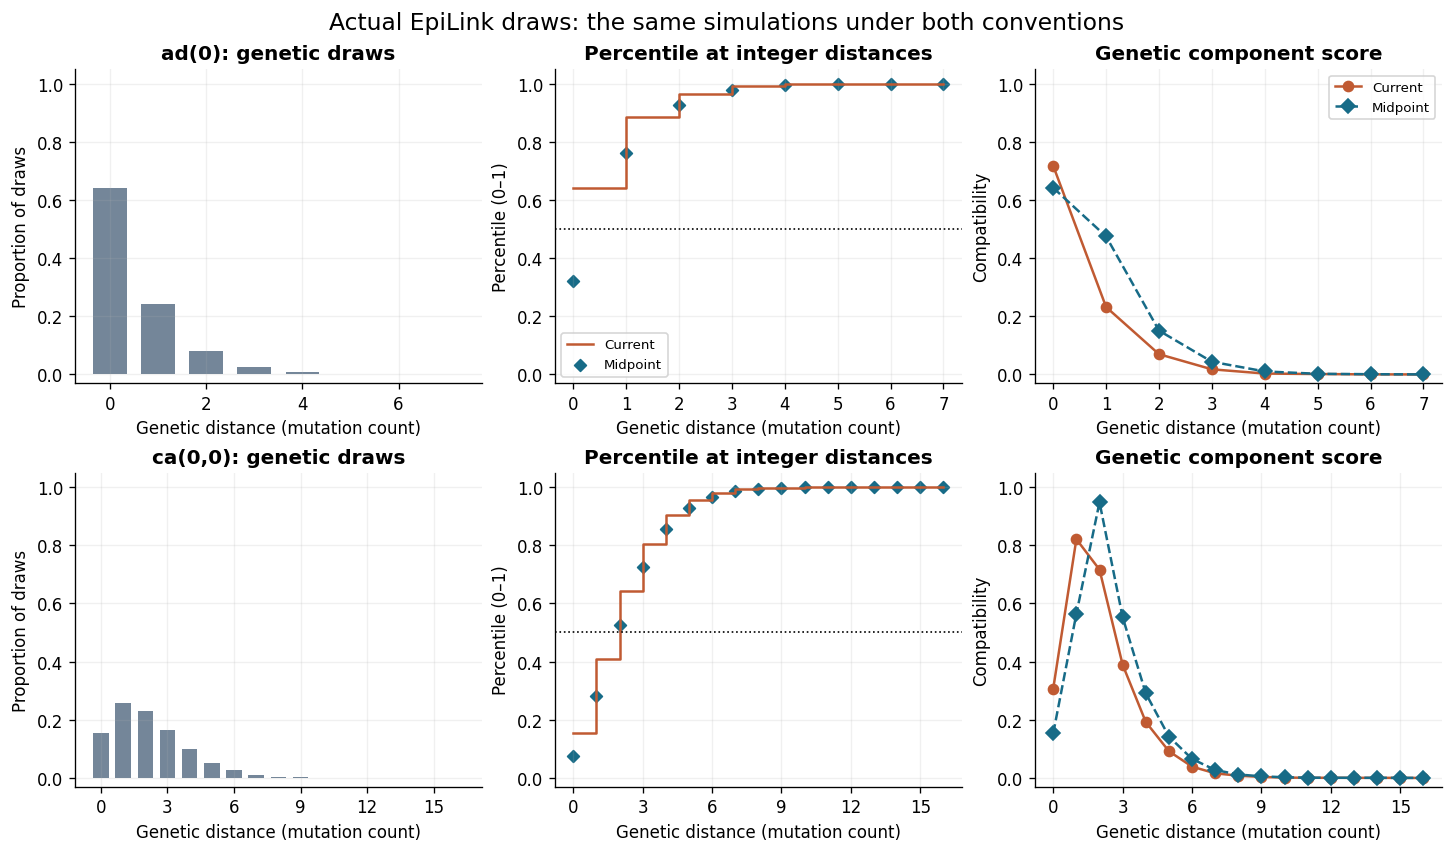

ad(0): 64.1% zero draws; score at zero 0.717 (current) versus 0.641 (midpoint).
ca(0,0): 15.3% zero draws; score at zero 0.307 (current) versus 0.153 (midpoint).


In [ ]:
distribution_summaries = []
for label, draws in genetic_draws.items():
    table = score_table(draws)
    modes = table.loc[
        table["Count equal"] == table["Count equal"].max(), "Observed distance"
    ].tolist()
    zero = score_table(draws, [0]).iloc[0]
    distribution_summaries.append(
        {
            "Scenario": label,
            "Mean distance": draws.mean(),
            "Median distance": np.median(draws),
            "Mode(s)": str(modes),
            "Zero proportion": np.mean(draws == 0),
            "Current score at zero": zero["Current score"],
            "Midpoint score at zero": zero["Midpoint score"],
            "Best current score on support": table["Current score"].max(),
            "Best midpoint score on support": table["Midpoint score"].max(),
        }
    )
distribution_summary = pd.DataFrame(distribution_summaries).set_index("Scenario")
display(distribution_summary.round(4))

fig, axes = plt.subplots(2, 3, figsize=(12, 7), layout="constrained")
for row, (label, draws) in enumerate(genetic_draws.items()):
    # Show the complete simulated integer support, including zero-count gaps.
    support = np.arange(int(draws.max()) + 1)
    table = score_table(draws, support)
    axes[row, 0].bar(support, table["Mass at observation"], color=MASS, width=0.7)
    axes[row, 0].set(title=f"{label}: genetic draws", ylabel="Proportion of draws")
    axes[row, 1].step(
        support, table["F right"], where="post", color=CURRENT, label="Current"
    )
    axes[row, 1].scatter(
        support, table["F midpoint"], color=MIDPOINT, marker="D", s=25, label="Midpoint"
    )
    axes[row, 1].axhline(0.5, color="black", linestyle=":", linewidth=1)
    axes[row, 1].set(title="Percentile at integer distances", ylabel="Percentile (0–1)")
    axes[row, 2].plot(
        support, table["Current score"], "o-", color=CURRENT, label="Current"
    )
    axes[row, 2].plot(
        support, table["Midpoint score"], "D--", color=MIDPOINT, label="Midpoint"
    )
    axes[row, 2].set(title="Genetic component score", ylabel="Compatibility")
    for ax in axes[row]:
        ax.set(xlabel="Genetic distance (mutation count)", ylim=(-0.03, 1.05))
        ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True, nbins=8))
axes[0, 1].legend(fontsize=8)
axes[0, 2].legend(fontsize=8)
fig.suptitle(
    "Actual EpiLink draws: the same simulations under both conventions", fontsize=14
)
plt.show()

for label, row in distribution_summary.iterrows():
    print(
        f"{label}: {row['Zero proportion']:.1%} zero draws; score at zero "
        f"{row['Current score at zero']:.3f} (current) versus "
        f"{row['Midpoint score at zero']:.3f} (midpoint)."
    )

Lines joining genetic scores in the preceding plot guide the eye between integer observations; they do not specify interpolation for fractional distances. To calculate a fractional observation, use the empirical-percentile functions directly.

### Deterministic genetic inference can also contain ties

Deterministic genetic inference uses expected mutation counts rather than Poisson draws. That does not guarantee a tie-free distribution. In the inspected implementation, the ancestor–descendant branch length is clipped at zero. Those zero branch lengths also give exactly zero expected mutations. The next check reports this feature rather than assuming that ties are exclusive to stochastic inference.


In [ ]:
deterministic_model = EpiLink(
    transmission_profile=InfectiousnessToTransmission(
        parameters=parameters, rng_seed=SEED
    ),
    maximum_depth=0,
    mc_samples=MC_SAMPLES,
    target=["ad(0)", "ca(0,0)"],
    mutation_process="deterministic",
)
deterministic_rows = []
for label, draws in deterministic_model.draws_by_scenario.items():
    values = draws["genetic_draws"]
    zero = score_table(values, [0]).iloc[0]
    deterministic_rows.append(
        {
            "Scenario": label,
            "Unique values": np.unique(values).size,
            "Zero branch proportion": np.mean(draws["branch_draws"] == 0),
            "Zero genetic proportion": np.mean(values == 0),
            "Current score at zero": zero["Current score"],
            "Midpoint score at zero": zero["Midpoint score"],
        }
    )
display(pd.DataFrame(deterministic_rows).set_index("Scenario").round(4))

,Unique values,Zero branch proportion,Zero genetic proportion,Current score at zero,Midpoint score at zero
Scenario,,,,,
ad(0),9110,0.0891,0.0891,0.1782,0.0891
"ca(0,0)",10000,0.0000,0.0000,0.0000,0.0000


## 5. Propagation to the combined score

EpiLink multiplies the temporal and genetic components within each scenario and then sums across the target set:

$$
C(t,g)=\sum_{s\in\{\mathrm{ad}(0),\mathrm{ca}(0,0)\}}
c(F_{T,s}(t))\,c(F_{G,s}(g)).
$$

To isolate the genetic tie convention, the alternative below changes **only the genetic percentile**. It keeps the temporal convention, simulated arrays, target set, and parameters fixed. It does not alter the package scorer or its caches.

The grid contains hypothetical observed pairs, not labelled test cases. It illustrates where edge weights could change; it cannot establish changes in average precision, cluster membership, or epidemiological accuracy. With two scenarios the total score can exceed 1.


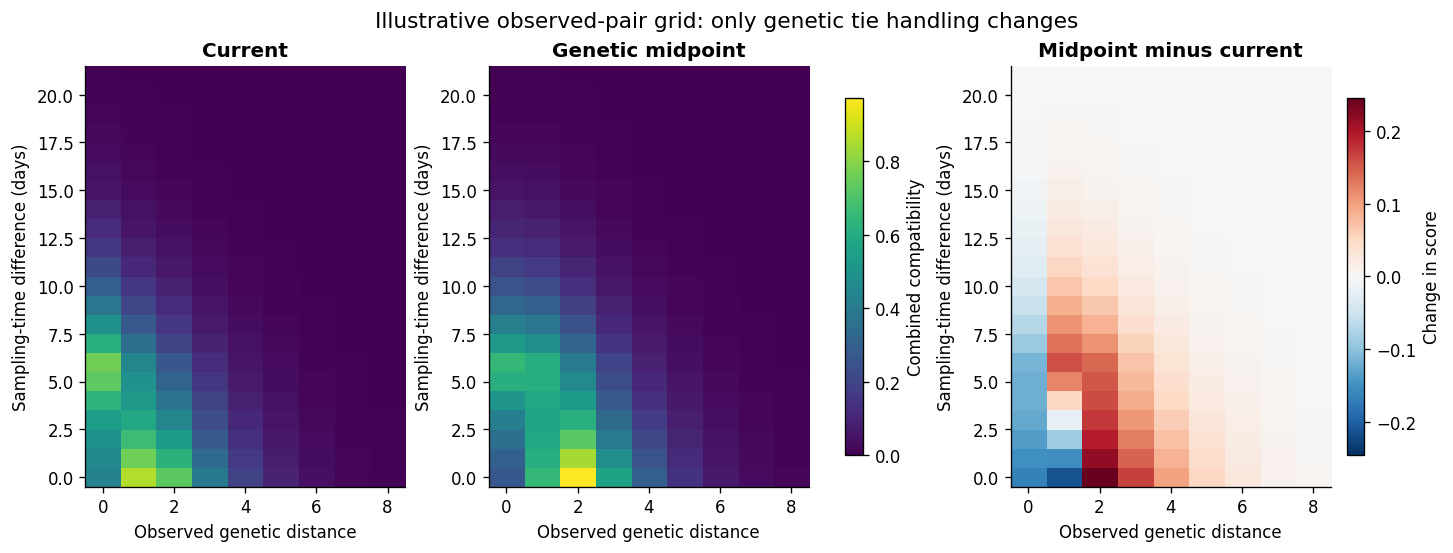

,Illustrative grid only
Grid points,198.000000
Fraction of grid points changed,1.000000
Largest absolute score change,0.245471
Mean absolute score change (uniform grid),0.032333


Current notebook scorer matches both EpiLink APIs; non-integer nonmatches are unchanged.


In [ ]:
def score_with_genetic_convention(
    model, sample_time_difference, genetic_distance, convention
):
    times, genetics = np.broadcast_arrays(
        np.asarray(sample_time_difference, dtype=float),
        np.asarray(genetic_distance, dtype=float),
    )
    result = np.zeros(times.shape, dtype=float)
    for label in model.target_labels:
        draws = model.draws_by_scenario[label]
        temporal_score = compatibility(
            empirical_percentiles(draws["time_draws"], times, "right")
        )
        genetic_score = compatibility(
            empirical_percentiles(draws["genetic_draws"], genetics, convention)
        )
        result += temporal_score * genetic_score
    return result


time_values = np.arange(0, 22, dtype=float)
genetic_values = np.arange(0, 9, dtype=float)
times = time_values[:, None]
genetics = genetic_values[None, :]
current_grid = score_with_genetic_convention(model, times, genetics, "right")
midpoint_grid = score_with_genetic_convention(model, times, genetics, "midpoint")
np.testing.assert_allclose(
    current_grid, model.score_target(times, genetics), atol=1e-12
)
for t, g in [(0, 0), (3, 1), (7, 2), (14, 0.25)]:
    np.testing.assert_allclose(
        score_with_genetic_convention(model, t, g, "right"),
        model.score_pair(
            sample_time_difference=t, genetic_distance=g
        ).target_compatibility,
    )

fractional_genetics = np.arange(0.25, 8.5, 0.5)[None, :]
np.testing.assert_allclose(
    score_with_genetic_convention(model, times, fractional_genetics, "right"),
    score_with_genetic_convention(model, times, fractional_genetics, "midpoint"),
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), layout="constrained")
shared_max = max(current_grid.max(), midpoint_grid.max())
extent = (-0.5, 8.5, -0.5, 21.5)
for ax, values, title in zip(
    axes[:2], [current_grid, midpoint_grid], ["Current", "Genetic midpoint"]
):
    im = ax.imshow(
        values,
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=0,
        vmax=shared_max,
        cmap="viridis",
    )
    ax.set_title(title)
fig.colorbar(im, ax=axes[:2], label="Combined compatibility", shrink=0.85)
difference = midpoint_grid - current_grid
limit = max(np.abs(difference).max(), 1e-12)
im_difference = axes[2].imshow(
    difference,
    origin="lower",
    aspect="auto",
    extent=extent,
    vmin=-limit,
    vmax=limit,
    cmap="RdBu_r",
)
axes[2].set_title("Midpoint minus current")
fig.colorbar(im_difference, ax=axes[2], label="Change in score", shrink=0.85)
for ax in axes:
    ax.grid(False)
    ax.set(
        xlabel="Observed genetic distance",
        ylabel="Sampling-time difference (days)",
        xticks=[0, 2, 4, 6, 8],
    )
fig.suptitle(
    "Illustrative observed-pair grid: only genetic tie handling changes", fontsize=13
)
plt.show()

grid_summary = pd.Series(
    {
        "Grid points": current_grid.size,
        "Fraction of grid points changed": np.mean(np.abs(difference) > 1e-12),
        "Largest absolute score change": np.abs(difference).max(),
        "Mean absolute score change (uniform grid)": np.abs(difference).mean(),
    },
    name="Illustrative grid only",
)
display(grid_summary.to_frame())
print(
    "Current notebook scorer matches both EpiLink APIs; non-integer nonmatches are unchanged."
)

## 6. Interpretation and the next empirical comparison

**What this notebook establishes**

- The current code implements a right-inclusive empirical CDF correctly. The concern is the interpretation of its transformed value as compatibility with discrete outcomes.
- Large tied masses can depress the score of a common or even universal observation. This is more than a failure to reach exactly 1.
- Midpoint percentiles remove the specific asymmetry illustrated by the 90%-zero, all-zero, and 30–40–30 examples. They remain a design choice and do not turn the score into a likelihood, calibrated probability, or universal measure of typicality.
- The impact depends on the scenario, parameters, and observed distances. The EpiLink tables quantify the effect for the explicit baseline and seed above. Differences do not automatically disappear with more Monte Carlo draws.
- A tied value can affect combined weights, while a value strictly between integer draws is unchanged. Effects in an empirical dataset with scaled TN93 distances therefore cannot be inferred from an integer grid alone.

**What remains to be evaluated**

Before changing the package, compare both conventions using the same cached draws and observed pairs in the existing synthetic benchmark. First hold the target set, temporal rule, sparsification threshold, and Leiden resolution fixed, so the comparison isolates genetic tie handling. Report pairwise average precision, changes in retained edges and weights, and cluster precision, recall, and F1 against the existing reference memberships. Then assess sensitivity across parameter settings, random seeds, and resolutions. If settings are retuned, use the same selection procedure for both conventions and report that comparison separately.

The midpoint score is a **candidate for sensitivity analysis**, not an established improvement in epidemiological accuracy. This notebook intentionally leaves the production method and existing benchmark results unchanged.

### Sources and implementation locations

- [SciPy: `percentileofscore`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.percentileofscore.html) — `weak`, `strict`, `mean`, and `rank` conventions.
- [Local EpiLink source](../epilink/src/epilink/model/epilink.py) — `draws_by_scenario`, `_simulate_genetic_draws`, `percentile_score`, and `PairwiseCompatibilityModel._percentile_scores`. The execution-provenance table records the actual local source used.
- [Evaluation configuration](config.yaml) — Chapter 3 baseline parameters. This notebook embeds the inspected baseline explicitly and prints the resolved values.

No new epidemiological claim follows from the illustrative distributions alone.
